In [118]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [119]:
raw = mne.io.read_raw_edf("S001/S001R03.edf", preload=True)

print(raw)

<RawEDF | S001R03.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>


In [120]:
raw.ch_names

['Fc5.',
 'Fc3.',
 'Fc1.',
 'Fcz.',
 'Fc2.',
 'Fc4.',
 'Fc6.',
 'C5..',
 'C3..',
 'C1..',
 'Cz..',
 'C2..',
 'C4..',
 'C6..',
 'Cp5.',
 'Cp3.',
 'Cp1.',
 'Cpz.',
 'Cp2.',
 'Cp4.',
 'Cp6.',
 'Fp1.',
 'Fpz.',
 'Fp2.',
 'Af7.',
 'Af3.',
 'Afz.',
 'Af4.',
 'Af8.',
 'F7..',
 'F5..',
 'F3..',
 'F1..',
 'Fz..',
 'F2..',
 'F4..',
 'F6..',
 'F8..',
 'Ft7.',
 'Ft8.',
 'T7..',
 'T8..',
 'T9..',
 'T10.',
 'Tp7.',
 'Tp8.',
 'P7..',
 'P5..',
 'P3..',
 'P1..',
 'Pz..',
 'P2..',
 'P4..',
 'P6..',
 'P8..',
 'Po7.',
 'Po3.',
 'Poz.',
 'Po4.',
 'Po8.',
 'O1..',
 'Oz..',
 'O2..',
 'Iz..']

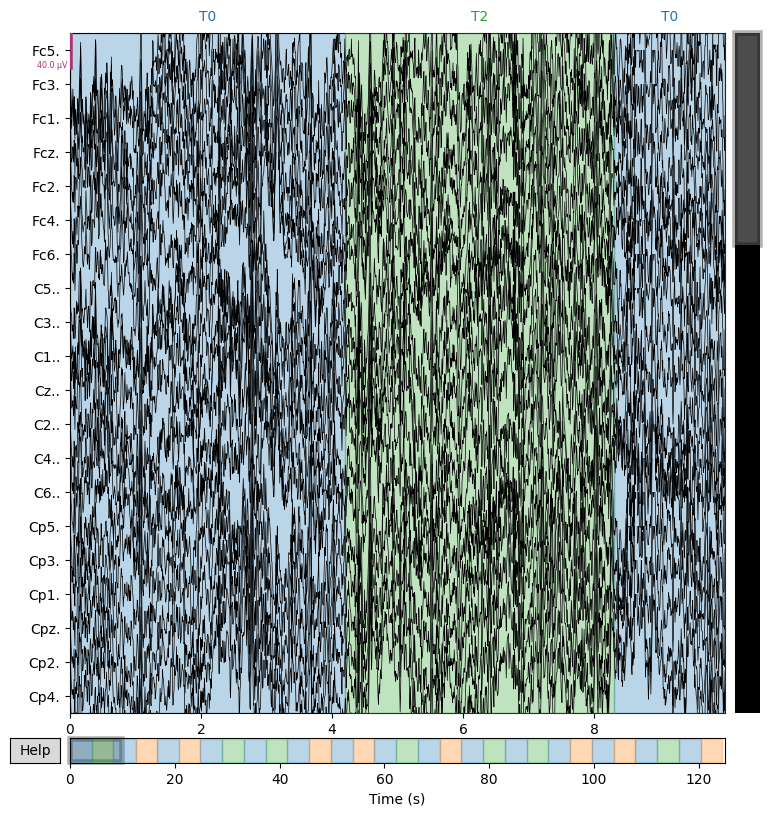

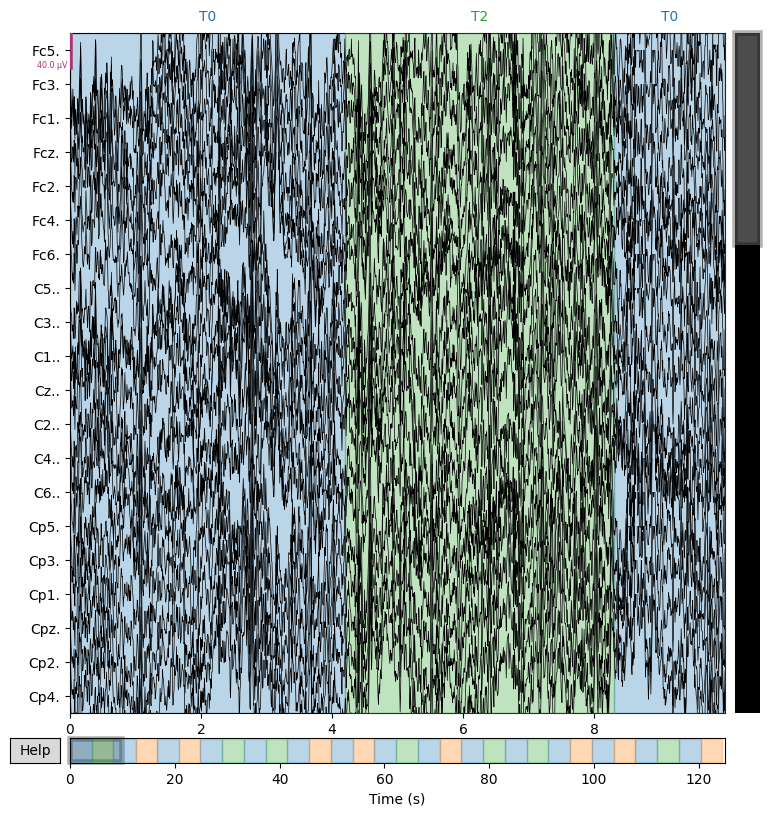

In [121]:
raw.plot()

In [122]:
events, event_dict = mne.events_from_annotations(raw)

print(event_dict)

{'T0': 1, 'T1': 2, 'T2': 3}


In [123]:
events[:4]

array([[   0,    0,    1],
       [ 672,    0,    3],
       [1328,    0,    1],
       [2000,    0,    2]])

In [124]:
epochs = mne.Epochs(
    raw,
    events,
    event_id={'left': 2, 'right': 3},
    tmin=0,
    tmax=2,
    baseline=None,
    preload=True
)

epochs

<Epochs | 15 events (all good), 0 – 2 s (baseline off), ~2.4 MiB, data loaded,
 'left': 8
 'right': 7>

In [125]:
epochs.get_data().shape

(15, 64, 321)

In [126]:
data = epochs.get_data()

features = data.mean(axis=2)

features.shape

(15, 64)

In [127]:
labels = epochs.events[:, 2]

labels

array([3, 2, 2, 3, 3, 2, 2, 3, 2, 3, 3, 2, 2, 3, 2])

In [128]:
labels = (labels == 3).astype(int)

labels

array([1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0])

In [129]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Split the data: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.3, random_state=42
)

# Create logistic regression model
clf = LogisticRegression(max_iter=1000)

# Train
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test Accuracy:", acc)
print("Confusion Matrix:\n", cm)

Test Accuracy: 0.4
Confusion Matrix:
 [[2 0]
 [3 0]]


In [130]:
import os
import mne
import numpy as np

subject_folder = 'S001'
hand_runs = ['R03', 'R04', 'R07', 'R08', 'R11', 'R12']

all_features = []
all_labels = []

for run in hand_runs:
    edf_file = os.path.join(subject_folder, f"{subject_folder}{run}.edf")
    # Load EDF
    raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
    
    # Pick EEG channels only
    raw.pick_types(eeg=True)
    
    # Load events from the annotations
    events, event_id = mne.events_from_annotations(raw)
    
    # Keep only left/right hand events (T1=left, T2=right)
    epochs = mne.Epochs(raw, events, event_id={'T1': 2, 'T2': 3},
                        tmin=0, tmax=2, baseline=None, preload=True, verbose=False)
    
    # Extract simple features: channel averages over the epoch
    data = epochs.get_data()
    features = data.mean(axis=2)  # shape: (n_trials, 64)
    labels = epochs.events[:, 2]
    labels = (labels == 3).astype(int)  # 0=left, 1=right
    
    # Append to all_features/all_labels
    all_features.append(features)
    all_labels.append(labels)

# Combine all runs
all_features = np.vstack(all_features)
all_labels = np.concatenate(all_labels)

print("Combined feature shape:", all_features.shape)
print("Combined labels shape:", all_labels.shape)

Combined feature shape: (90, 64)
Combined labels shape: (90,)


In [131]:
# Split 70% train / 30% test
X_train, X_test, y_train, y_test = train_test_split(
    all_features, all_labels, test_size=0.3, random_state=42
)

# Train logistic regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test Accuracy:", acc)
print("Confusion Matrix:\n", cm)

Test Accuracy: 0.5185185185185185
Confusion Matrix:
 [[14  0]
 [13  0]]


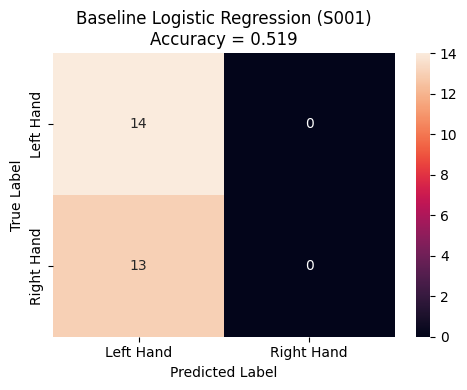

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# compute accuracy
acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=["Left Hand", "Right Hand"],
            yticklabels=["Left Hand", "Right Hand"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Baseline Logistic Regression (S001)\nAccuracy = {acc:.3f}")

plt.tight_layout()
plt.show()

In [133]:
# First, pick only the channels we care about
channels_of_interest = ['C3..', 'C4..']  # make sure these match your raw.ch_names
sfreq = raw.info['sfreq']  # sampling frequency

def band_power(epoch_data, sfreq, band):
    """Compute average power in a frequency band using FFT."""
    from scipy.signal import welch
    fmin, fmax = band
    psd = []
    for ch_data in epoch_data:
        f, Pxx = welch(ch_data, fs=sfreq, nperseg=sfreq*2)  # 2s window
        # Average power in band
        idx_band = (f >= fmin) & (f <= fmax)
        psd.append(Pxx[idx_band].mean())
    return np.array(psd)

# Define bands
bands = {'mu': (8, 12), 'beta': (13, 30)}

# Prepare feature array
bp_features = []

for run in hand_runs:
    edf_file = os.path.join(subject_folder, f"{subject_folder}{run}.edf")
    raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
    raw.pick_channels(channels_of_interest)
    
    events, event_id = mne.events_from_annotations(raw)
    epochs = mne.Epochs(raw, events, event_id={'T1': 2, 'T2': 3},
                        tmin=0, tmax=2, baseline=None, preload=True, verbose=False)
    
    data = epochs.get_data()  # shape: (n_trials, n_channels, n_times)
    labels = epochs.events[:, 2]
    labels = (labels == 3).astype(int)
    
    # Extract band powers
    for trial in data:
        trial_features = []
        for i, ch_data in enumerate(trial):
            for band_name, band_range in bands.items():
                bp = band_power([ch_data], sfreq, band_range)
                trial_features.append(bp[0])
        bp_features.append(trial_features)
    
bp_features = np.array(bp_features)
all_labels_bp = np.concatenate([ (epochs.events[:, 2] == 3).astype(int) for run in hand_runs])

print("Band power feature shape:", bp_features.shape)

Band power feature shape: (90, 4)


In [134]:
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(bp_features)  # shape: (90, 4)

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, all_labels_bp, test_size=0.3, random_state=42, stratify=all_labels_bp
)

# Train logistic regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test Accuracy:", acc)
print("Confusion Matrix:\n", cm)

Test Accuracy: 0.48148148148148145
Confusion Matrix:
 [[4 9]
 [5 9]]


In [135]:
C3_C4_mu = bp_features[:, 0] - bp_features[:, 2]    # C3_mu - C4_mu
C3_C4_beta = bp_features[:, 1] - bp_features[:, 3]  # C3_beta - C4_beta

X_diff = np.column_stack([C3_C4_mu, C3_C4_beta])     # shape: (n_trials, 2)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_diff)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, all_labels_bp, test_size=0.3, random_state=42, stratify=all_labels_bp
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test Accuracy:", acc)
print("Confusion Matrix:\n", cm)

Test Accuracy: 0.5925925925925926
Confusion Matrix:
 [[ 3 10]
 [ 1 13]]


In [136]:
# ----------------------------
# Parameters
subjects = [f"S{str(i).zfill(3)}" for i in range(1, 11)]
runs_to_use = [3, 7, 11]  # only real left/right hand movement runs for each subject
channels_of_interest = ['C3..', 'C4..']  # C3 and C4

# Mu (8–12 Hz) and Beta (13–30 Hz) bands
bands = {'mu': (8, 12), 'beta': (13, 30)}

all_features = []
all_labels = []

# ----------------------------
# Loop through subjects and runs
for subj in subjects:
    subj_folder = subj
    for run_num in runs_to_use:
        edf_file = os.path.join(subj_folder, f"{subj}R{str(run_num).zfill(2)}.edf")
        event_file = os.path.join(subj_folder, f"{subj}R{str(run_num).zfill(2)}.edf.event")
        
        # Load raw EEG
        raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
        events, event_id = mne.events_from_annotations(raw, verbose=False)
        
        # Pick only EEG channels
        raw.pick_channels(channels_of_interest)
        
        # Create epochs around T1 (left) and T2 (right)
        epochs = mne.Epochs(
            raw, events, event_id={'T1': 1, 'T2': 2},
            tmin=0.0, tmax=2.0, baseline=None, preload=True, verbose=False
        )
        
        labels = epochs.events[:, -1]
        
        # Compute band powers for each trial and channel
        bp_features = []
        for ep in epochs.get_data():  # ep shape: (n_channels, n_times)
            trial_feats = []
            for i_ch in range(ep.shape[0]):
                # Mu band power
                mu_power = np.mean(mne.filter.filter_data(ep[i_ch:i_ch+1, :], sfreq=raw.info['sfreq'], l_freq=bands['mu'][0], h_freq=bands['mu'][1], verbose=False)**2)
                # Beta band power
                beta_power = np.mean(mne.filter.filter_data(ep[i_ch:i_ch+1, :], sfreq=raw.info['sfreq'], l_freq=bands['beta'][0], h_freq=bands['beta'][1], verbose=False)**2)
                trial_feats.extend([mu_power, beta_power])
            bp_features.append(trial_feats)
        
        bp_features = np.array(bp_features)  # shape: (n_trials, 4) -> [C3_mu, C3_beta, C4_mu, C4_beta]
        
        # Contralateral differences
        C3_C4_mu = bp_features[:, 0] - bp_features[:, 2]
        C3_C4_beta = bp_features[:, 1] - bp_features[:, 3]
        X_diff = np.column_stack([C3_C4_mu, C3_C4_beta])
        
        all_features.append(X_diff)
        all_labels.append(np.array(labels) - 1)  # convert 1=T1->0, 2=T2->1

# ----------------------------
# Combine features and labels from all subjects
X = np.vstack(all_features)
y = np.hstack(all_labels)

# ----------------------------
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# ----------------------------
# Train logistic regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# ----------------------------
# Evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test Accuracy:", acc)
print("Confusion Matrix:\n", cm)

Test Accuracy: 0.6666666666666666
Confusion Matrix:
 [[136   0]
 [ 68   0]]


In [137]:
# Paths
subjects = [f"S{str(i).zfill(3)}" for i in range(1, 11)]
all_features = []
all_labels = []

# Event mapping
event_id = {'T0': 1, 'T1': 2, 'T2': 3}  # T1 = left hand, T2 = right hand

# Loop over subjects
for subj in subjects:
    subj_path = os.path.join('.', subj)
    files = sorted([f for f in os.listdir(subj_path) if f.endswith('.edf')])
    
    for f in files:
        raw = mne.io.read_raw_edf(os.path.join(subj_path, f), preload=True, verbose=False)
        annotations = raw.annotations
        events, _ = mne.events_from_annotations(raw)

        # Filter only left/right hand trials
        mask = np.isin(events[:, -1], [event_id['T1'], event_id['T2']])
        events_filtered = events[mask]

        # Skip run if less than 2 classes are present
        if len(np.unique(events_filtered[:, -1])) < 2:
            continue

        # Only include event IDs present in this run
        event_ids_present = {k: v for k, v in event_id.items() if v in events_filtered[:, -1]}

        # Create epochs
        epochs = mne.Epochs(raw, events_filtered, event_id=event_ids_present,
                            tmin=0, tmax=2, baseline=None, preload=True, verbose=False)
        
        # Pick C3 and C4 channels
        picks = mne.pick_channels(epochs.info["ch_names"], include=['C3..', 'C4..'])
        epochs_picked = epochs.get_data()[:, picks, :]  # shape: (n_epochs, 2, n_times)

        # Compute simple band power: mu (8-13 Hz) and beta (13-30 Hz)
        sfreq = raw.info['sfreq']
        def band_power(data, sfreq, fmin, fmax):
            psd, freqs = mne.time_frequency.psd_array_welch(data, sfreq=sfreq, fmin=fmin, fmax=fmax, verbose=False)
            return psd.mean(axis=-1)  # mean power per epoch

        mu_power = np.array([band_power(epoch, sfreq, 8, 13) for epoch in epochs_picked])
        beta_power = np.array([band_power(epoch, sfreq, 13, 30) for epoch in epochs_picked])

        # mu/beta features: C3-C4 difference
        C3_C4_mu = mu_power[:, 0] - mu_power[:, 1]
        C3_C4_beta = beta_power[:, 0] - beta_power[:, 1]
        features = np.column_stack([C3_C4_mu, C3_C4_beta])

        # Labels: map left hand = 0, right hand = 1
        labels = np.array([0 if e == event_id['T1'] else 1 for e in events_filtered[:, -1]])

        all_features.append(features)
        all_labels.append(labels)

# Combine all subjects
X = np.vstack(all_features)
y = np.hstack(all_labels)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Train logistic regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test Accuracy:", acc)
print("Confusion Matrix:\n", cm)

Test Accuracy: 0.5148148148148148
Confusion Matrix:
 [[134 137]
 [125 144]]


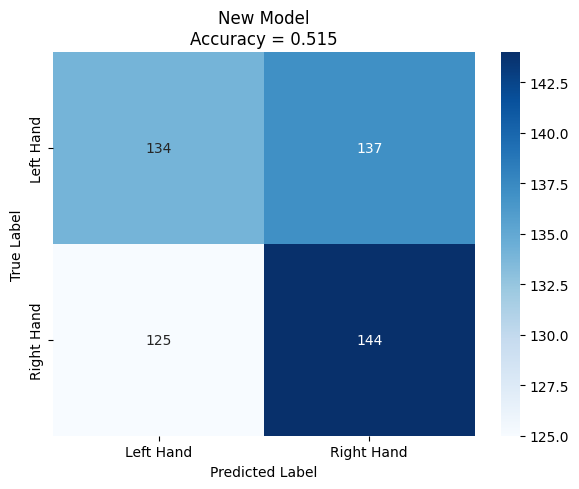

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Left Hand', 'Right Hand'],
            yticklabels=['Left Hand', 'Right Hand'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"New Model\nAccuracy = {acc:.3f}")

plt.tight_layout()
plt.show()

In [139]:
"final subject-dependent model"

'final subject-dependent model'

In [140]:
from mne.decoding import CSP
import os
import mne
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

# -------------------------------
# PARAMETERS
# -------------------------------
subjects = [f"S{str(i).zfill(3)}" for i in range(1, 11)]
tmin, tmax = 0, 2  # epoch window in seconds
event_id = {'T1': 1, 'T2': 2}  # left/right hand

all_results = {}

# -------------------------------
# LOOP OVER SUBJECTS
# -------------------------------
for subj in subjects:
    print(f"\nProcessing {subj}...")
    
    # List of EDF files for this subject
    subj_files = [f"{subj}/{f}" for f in os.listdir(subj) if f.endswith('.edf')]
    
    X_subj = []
    y_subj = []
    
    for fpath in subj_files:
        raw = mne.io.read_raw_edf(fpath, preload=True, verbose=False)
        
        # Convert annotations to events
        events, _ = mne.events_from_annotations(raw)
        
        # Keep only left/right hand events that exist in this run
        existing_ids = [eid for eid in [1, 2] if eid in events[:, -1]]
        if len(existing_ids) < 2:
            # Skip run if missing either class
            continue
        
        event_id_run = {k: v for k, v in event_id.items() if v in existing_ids}
        epochs = mne.Epochs(
            raw,
            events,
            event_id=event_id_run,
            tmin=tmin,
            tmax=tmax,
            baseline=None,
            preload=True,
            verbose=False
        )
        
        # Only keep trials with present event IDs
        keep_mask = np.isin(epochs.events[:, -1], existing_ids)
        epochs = epochs[keep_mask]
        
        # Get data and labels
        X_run = epochs.get_data()  # (n_epochs, n_channels, n_times)
        y_run = epochs.events[:, -1] - 1  # convert 1/2 -> 0/1
        
        X_subj.append(X_run)
        y_subj.append(y_run)
    
    if len(X_subj) == 0:
        print(f"No valid runs for {subj}, skipping.")
        continue
    
    X_subj = np.concatenate(X_subj, axis=0)
    y_subj = np.concatenate(y_subj, axis=0)
    
    # Fit CSP (two components per class)
    csp = CSP(n_components=2, reg=None, log=True, norm_trace=False)
    X_csp = csp.fit_transform(X_subj, y_subj)
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_csp)
    
    # Train/test split (subject-dependent)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled,
        y_subj,
        test_size=0.3,
        random_state=42,
        stratify=y_subj
    )
    
    # Logistic Regression
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"{subj} Test Accuracy: {acc:.3f}")
    print(f"{subj} Confusion Matrix:\n{cm}")
    
    all_results[subj] = {"accuracy": acc, "confusion_matrix": cm}


Processing S001...
S001 Test Accuracy: 0.679
S001 Confusion Matrix:
[[47  7]
 [19  8]]

Processing S002...
S002 Test Accuracy: 0.659
S002 Confusion Matrix:
[[54  0]
 [28  0]]

Processing S003...
S003 Test Accuracy: 0.753
S003 Confusion Matrix:
[[50  4]
 [16 11]]

Processing S004...
S004 Test Accuracy: 0.951
S004 Confusion Matrix:
[[52  2]
 [ 2 25]]

Processing S005...
S005 Test Accuracy: 0.667
S005 Confusion Matrix:
[[54  0]
 [27  0]]

Processing S006...
S006 Test Accuracy: 0.667
S006 Confusion Matrix:
[[54  0]
 [27  0]]

Processing S007...
S007 Test Accuracy: 0.938
S007 Confusion Matrix:
[[51  3]
 [ 2 25]]

Processing S008...
S008 Test Accuracy: 0.963
S008 Confusion Matrix:
[[53  1]
 [ 2 25]]

Processing S009...
S009 Test Accuracy: 0.817
S009 Confusion Matrix:
[[48  6]
 [ 9 19]]

Processing S010...
S010 Test Accuracy: 0.819
S010 Confusion Matrix:
[[47  8]
 [ 7 21]]


In [141]:
import os
import mne
import numpy as np
from mne.decoding import CSP
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

# -------------------------------
# PARAMETERS
# -------------------------------
train_subjects = [f"S{str(i).zfill(3)}" for i in range(1, 11)]
test_subject = "S011"  # new subject
tmin, tmax = 0, 2
channels_of_interest = ['C3..', 'C4..']
event_id_map = {'T1': 1, 'T2': 2}  # left=0, right=1
calibration_trials_per_class = 5
n_csp_components = 4

# -------------------------------
# LOAD TRAINING SUBJECTS
# -------------------------------
X_train_list, y_train_list = [], []

for subj in train_subjects:
    subj_files = [f for f in os.listdir(subj) if f.endswith('.edf')]
    X_subj, y_subj = [], []
    for fpath in subj_files:
        raw = mne.io.read_raw_edf(os.path.join(subj, fpath), preload=True, verbose=False)
        events, _ = mne.events_from_annotations(raw)
        keep_mask = np.isin(events[:, 2], [1, 2])
        events = events[keep_mask]
        if len(np.unique(events[:, 2])) < 2:
            continue

        epochs = mne.Epochs(raw, events, event_id={k:v for k,v in event_id_map.items() if v in events[:,2]},
                            tmin=tmin, tmax=tmax, baseline=None, preload=True, verbose=False)
        keep_mask = np.isin(epochs.events[:, -1], [1, 2])
        epochs = epochs[keep_mask]
        X_subj.append(epochs.get_data())
        y_subj.append(epochs.events[:, -1] - 1)  # 1/2 -> 0/1

    if len(X_subj) == 0:
        continue
    X_train_list.append(np.concatenate(X_subj, axis=0))
    y_train_list.append(np.concatenate(y_subj, axis=0))

X_train_all = np.concatenate(X_train_list, axis=0)
y_train_all = np.concatenate(y_train_list, axis=0)

# -------------------------------
# LOAD TEST SUBJECT
# -------------------------------
subj_files = [f for f in os.listdir(test_subject) if f.endswith('.edf')]
X_test_subj, y_test_subj = [], []
for fpath in subj_files:
    raw = mne.io.read_raw_edf(os.path.join(test_subject, fpath), preload=True, verbose=False)
    events, _ = mne.events_from_annotations(raw)
    keep_mask = np.isin(events[:, 2], [1, 2])
    events = events[keep_mask]
    if len(np.unique(events[:, 2])) < 2:
        continue

    epochs = mne.Epochs(raw, events, event_id={k:v for k,v in event_id_map.items() if v in events[:,2]},
                        tmin=tmin, tmax=tmax, baseline=None, preload=True, verbose=False)
    keep_mask = np.isin(epochs.events[:, -1], [1, 2])
    epochs = epochs[keep_mask]
    X_test_subj.append(epochs.get_data())
    y_test_subj.append(epochs.events[:, -1] - 1)

X_test_subj = np.concatenate(X_test_subj, axis=0)
y_test_subj = np.concatenate(y_test_subj, axis=0)

# -------------------------------
# FIT CSP ON TRAINING SUBJECTS
# -------------------------------
csp = CSP(n_components=n_csp_components, reg=None, log=True, norm_trace=False)
X_train_csp = csp.fit_transform(X_train_all, y_train_all)
X_test_csp = csp.transform(X_test_subj)

# -------------------------------
# SCALE FEATURES
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_csp)
X_test_scaled = scaler.transform(X_test_csp)

# -------------------------------
# SPLIT TEST SUBJECT FOR CALIBRATION
# -------------------------------
calib_idx = []
for cls in [0,1]:
    cls_idx = np.where(y_test_subj == cls)[0][:calibration_trials_per_class]
    calib_idx.extend(cls_idx)
calib_idx = np.array(calib_idx)
test_idx = np.setdiff1d(np.arange(len(y_test_subj)), calib_idx)

X_calib, y_calib = X_test_scaled[calib_idx], y_test_subj[calib_idx]
X_test_final, y_test_final = X_test_scaled[test_idx], y_test_subj[test_idx]

# -------------------------------
# TRAIN CLASSIFIER ON TRAINING + CALIBRATION
# -------------------------------
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(np.vstack([X_train_scaled, X_calib]), np.hstack([y_train_all, y_calib]))

# -------------------------------
# EVALUATE
# -------------------------------
y_pred = clf.predict(X_test_final)
acc = accuracy_score(y_test_final, y_pred)
cm = confusion_matrix(y_test_final, y_pred)

print(f"Test Accuracy (after minimal calibration): {acc:.3f}")
print("Confusion Matrix:\n", cm)

Test Accuracy (after minimal calibration): 0.371
Confusion Matrix:
 [[ 28 147]
 [ 16  68]]


In [142]:
"final generalized model"

'final generalized model'

In [143]:
import os
import mne
import numpy as np
from mne.decoding import CSP
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# -------------------------------
# PARAMETERS
# -------------------------------
train_subjects = [f"S{str(i).zfill(3)}" for i in range(1, 11)]
test_subject = "S011"  # new subject
tmin, tmax = 0, 2
event_id_map = {'T1': 1, 'T2': 2}  # left/right
calibration_trials_per_class = 5
n_csp_components = 8  # more CSP components
random_state = 42

np.random.seed(random_state)

# -------------------------------
# LOAD TRAINING DATA
# -------------------------------
X_train_list, y_train_list = [], []

for subj in train_subjects:
    subj_files = [f for f in os.listdir(subj) if f.endswith('.edf')]
    X_subj, y_subj = [], []

    for fpath in subj_files:
        raw = mne.io.read_raw_edf(os.path.join(subj, fpath), preload=True, verbose=False)
        events, _ = mne.events_from_annotations(raw)
        keep_mask = np.isin(events[:, 2], [1, 2])
        events = events[keep_mask]

        if len(np.unique(events[:, 2])) < 2:
            continue

        event_id_run = {k: v for k, v in event_id_map.items() if v in events[:, 2]}
        epochs = mne.Epochs(raw, events, event_id=event_id_run, tmin=tmin, tmax=tmax,
                            baseline=None, preload=True, verbose=False)
        keep_mask = np.isin(epochs.events[:, -1], [1, 2])
        epochs = epochs[keep_mask]

        X_subj.append(epochs.get_data())
        y_subj.append(epochs.events[:, -1] - 1)

    if len(X_subj) == 0:
        continue

    X_train_list.append(np.concatenate(X_subj, axis=0))
    y_train_list.append(np.concatenate(y_subj, axis=0))

X_train_all = np.concatenate(X_train_list, axis=0)
y_train_all = np.concatenate(y_train_list, axis=0)

# -------------------------------
# LOAD TEST SUBJECT
# -------------------------------
subj_files = [f for f in os.listdir(test_subject) if f.endswith('.edf')]
X_test_subj, y_test_subj = [], []

for fpath in subj_files:
    raw = mne.io.read_raw_edf(os.path.join(test_subject, fpath), preload=True, verbose=False)
    events, _ = mne.events_from_annotations(raw)
    keep_mask = np.isin(events[:, 2], [1, 2])
    events = events[keep_mask]

    if len(np.unique(events[:, 2])) < 2:
        continue

    event_id_run = {k: v for k, v in event_id_map.items() if v in events[:, 2]}
    epochs = mne.Epochs(raw, events, event_id=event_id_run, tmin=tmin, tmax=tmax,
                        baseline=None, preload=True, verbose=False)
    keep_mask = np.isin(epochs.events[:, -1], [1, 2])
    epochs = epochs[keep_mask]

    X_test_subj.append(epochs.get_data())
    y_test_subj.append(epochs.events[:, -1] - 1)

X_test_subj = np.concatenate(X_test_subj, axis=0)
y_test_subj = np.concatenate(y_test_subj, axis=0)

# -------------------------------
# SPLIT TEST SUBJECT FOR CALIBRATION
# -------------------------------
calib_idx = []
for cls in [0, 1]:
    cls_idx_all = np.where(y_test_subj == cls)[0]
    cls_idx = np.random.choice(cls_idx_all, calibration_trials_per_class, replace=False)
    calib_idx.extend(cls_idx)
calib_idx = np.array(calib_idx)
test_idx = np.setdiff1d(np.arange(len(y_test_subj)), calib_idx)

X_calib = X_test_subj[calib_idx]
y_calib = y_test_subj[calib_idx]
X_test_final = X_test_subj[test_idx]
y_test_final = y_test_subj[test_idx]

# -------------------------------
# FIT CSP ON TRAINING + CALIBRATION
# -------------------------------
csp = CSP(n_components=n_csp_components, reg='ledoit_wolf', log=True, norm_trace=False)
X_csp_all = csp.fit_transform(np.vstack([X_train_all, X_calib]),
                             np.hstack([y_train_all, y_calib]))

X_train_csp = X_csp_all[:len(X_train_all)]
X_calib_csp = X_csp_all[len(X_train_all):]
X_test_csp = csp.transform(X_test_final)

# -------------------------------
# SCALE FEATURES
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_csp)
X_calib_scaled = scaler.transform(X_calib_csp)
X_test_scaled = scaler.transform(X_test_csp)

# -------------------------------
# TRAIN CLASSIFIER
# -------------------------------
clf = LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear')
clf.fit(np.vstack([X_train_scaled, X_calib_scaled]),
        np.hstack([y_train_all, y_calib]))

# -------------------------------
# EVALUATE
# -------------------------------
y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test_final, y_pred)
cm = confusion_matrix(y_test_final, y_pred)

print(f"Test Accuracy (after minimal calibration): {acc:.3f}")
print("Confusion Matrix:\n", cm)

Test Accuracy (after minimal calibration): 0.436
Confusion Matrix:
 [[ 51 124]
 [ 22  62]]


In [144]:
"subject depedent model function"

'subject depedent model function'

In [145]:
import os
import mne
import numpy as np
from mne.decoding import CSP
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

def subject_hand_classifier(subjects, tmin=0, tmax=2, n_csp=2, test_size=0.3, random_state=42):
    event_id = {'T1': 1, 'T2': 2}
    results = {}
    
    for subj in subjects:
        print(f"\nProcessing {subj}...")
        subj_files = [f"{subj}/{f}" for f in os.listdir(subj) if f.endswith('.edf')]
        
        X_subj, y_subj = [], []
        for fpath in subj_files:
            raw = mne.io.read_raw_edf(fpath, preload=True, verbose=False)
            events, _ = mne.events_from_annotations(raw)
            existing_ids = [eid for eid in [1, 2] if eid in events[:, -1]]
            if len(existing_ids) < 2:
                continue
            
            event_id_run = {k: v for k, v in event_id.items() if v in existing_ids}
            epochs = mne.Epochs(raw, events, event_id=event_id_run,
                                tmin=tmin, tmax=tmax, baseline=None,
                                preload=True, verbose=False)
            keep_mask = np.isin(epochs.events[:, -1], existing_ids)
            epochs = epochs[keep_mask]
            X_subj.append(epochs.get_data())
            y_subj.append(epochs.events[:, -1] - 1)
        
        if not X_subj:
            print(f"No valid runs for {subj}, skipping.")
            continue
        
        X_subj = np.concatenate(X_subj, axis=0)
        y_subj = np.concatenate(y_subj, axis=0)
        
        csp = CSP(n_components=n_csp, reg=None, log=True, norm_trace=False)
        X_csp = csp.fit_transform(X_subj, y_subj)
        X_scaled = StandardScaler().fit_transform(X_csp)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y_subj, test_size=test_size,
            random_state=random_state, stratify=y_subj
        )
        
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        
        print(f"{subj} Test Accuracy: {acc:.3f}")
        print(f"{subj} Confusion Matrix:\n{cm}")
        results[subj] = {"accuracy": acc, "confusion_matrix": cm}
    
    return results

In [146]:
results = subject_hand_classifier(['S004'])


Processing S004...
S004 Test Accuracy: 0.951
S004 Confusion Matrix:
[[52  2]
 [ 2 25]]


In [147]:
import os
import mne
import numpy as np
from mne.decoding import CSP
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

def subject_foot_classifier(subjects, tmin=0, tmax=2, n_csp=2, test_size=0.3, random_state=42):
    results = {}
    
    for subj in subjects:
        print(f"\nProcessing {subj}...")
        subj_files = [f"{subj}/{f}" for f in os.listdir(subj) if f.endswith('.edf')]
        
        X_subj, y_subj = [], []
        for fpath in subj_files:
            raw = mne.io.read_raw_edf(fpath, preload=True, verbose=False)
            descs = raw.annotations.description
            # Only use runs that contain both T1 (LF) and T2 (RF)
            available = {d: i+1 for i, d in enumerate(['T1','T2']) if d in descs}
            if len(available) < 2:
                continue
            
            events, _ = mne.events_from_annotations(raw, event_id=available)
            # Map numeric events to 0 (LF) and 1 (RF)
            y_vals = np.array([0 if ev==available['T1'] else 1 for ev in events[:, -1]])
            
            epochs = mne.Epochs(raw, events, event_id=available,
                                tmin=tmin, tmax=tmax, baseline=None,
                                preload=True, verbose=False)
            X_subj.append(epochs.get_data())
            y_subj.append(y_vals)
        
        if not X_subj:
            print(f"No valid runs for {subj}, skipping.")
            continue
        
        X_subj = np.concatenate(X_subj, axis=0)
        y_subj = np.concatenate(y_subj, axis=0)
        
        csp = CSP(n_components=n_csp, reg=None, log=True, norm_trace=False)
        X_csp = csp.fit_transform(X_subj, y_subj)
        X_scaled = StandardScaler().fit_transform(X_csp)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y_subj, test_size=test_size,
            random_state=random_state, stratify=y_subj
        )
        
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        
        print(f"{subj} Test Accuracy: {acc:.3f}")
        print(f"{subj} Confusion Matrix:\n{cm}")
        results[subj] = {"accuracy": acc, "confusion_matrix": cm}
    
    return results


In [148]:
mne.set_log_level('WARNING')

results = subject_foot_classifier(['S004'])


Processing S004...
S004 Test Accuracy: 0.833
S004 Confusion Matrix:
[[24  3]
 [ 6 21]]
